# Grid refinement in a restart chain

Three runs of the same quartz column, all reaching 5000 yr on a 400-cell grid or its equivalent:

| run | what it does | wall clock |
|---|---|---|
| `quartz_fine_reference.yaml` | cold start, 400 cells throughout | 56 s |
| `quartz_refine_chain.yaml` | 100 cells to 4500 yr, then `refine: 4` for the last 500 yr | 21 s |
| `quartz_graded_chain.yaml` | 100 cells, then 100 graded cells concentrated at the inlet | 17 s |

The question this notebook answers is not whether the chain is faster — it plainly is — but
**where the answer it gives differs from the cold start, and why**.

In [1]:
# The three sweeps have to have been run before this notebook can read them. Checked here
# rather than left to fail inside netCDF4, which reports an absolute path and no reason.
from pathlib import Path

missing = [name for name in ['quartz_fine_reference.nc', 'quartz_refine_chain.nc', 'quartz_graded_chain.nc']
           if not (Path.cwd() / name).exists()]
if missing:
    raise FileNotFoundError(
        f'{", ".join(missing)} not found — run the three sweeps in section 2 first.'
    )


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

# Wall clock as measured on the machine that produced the committed netCDF files. Rerunning
# will not reproduce these exactly, but the ratio between them is the point.
WALL_CLOCK = {'400 cells,\ncold start': 56, 'refine: 4\nchain': 21, 'graded\nchain': 17}


def profile(run, group, variable, time):
    """One stage's spatial profile, with the cells that stage did not cover dropped.

    A grid-varying chain reports every stage on one X coordinate and leaves NaN where a stage
    had no cell, so a stage's own profile is the non-NaN part of its time slice.
    """
    data = xr.open_dataset(f'{run}.nc', group=group)[variable]
    data = data.isel(file_num=0, Y=0, Z=0).sel(time=time)
    covered = ~np.isnan(data.values)

    return data.X.values[covered], data.values[covered]

## What is in the files

The chain writes both stages into one `results.nc`. The coarse stage's cells are placed at their
nearest position on the fine grid and everything else is NaN, so nothing is invented and the coarse
spin-up is still there to look at.

In [3]:
for run in ('quartz_fine_reference', 'quartz_refine_chain', 'quartz_graded_chain'):
    dataset = xr.open_dataset(f'{run}.nc', group='totcon')
    series = dataset['SiO2(aq)'].isel(file_num=0, Y=0, Z=0)
    covered = [int(np.sum(~np.isnan(series.isel(time=i).values))) for i in range(dataset.sizes['time'])]
    print(f'{run:24s} X = {dataset.sizes["X"]:3d}   '
          f'times = {[float(t) for t in dataset.time.values]}   cells covered = {covered}')

quartz_fine_reference    X = 400   times = [4500.0, 5000.0]   cells covered = [400, 400]
quartz_refine_chain      X = 400   times = [4500.0, 5000.0]   cells covered = [100, 400]
quartz_graded_chain      X = 200   times = [4500.0, 5000.0]   cells covered = [100, 100]


The graded chain keeps 200 X positions rather than 100. Its two grids do not nest — the second is
four times finer over the first 20 m and four times *coarser* over the remaining 80 — so neither can
hold the other's cells without collision, and the union is kept instead. That is reported when it
happens.

In [4]:
# The reference writes both 4500 and 5000 yr so that every comparison below is between two
# profiles at the SAME time. Comparing the coarse stage at 4500 against the cold start at 5000
# would fold 500 yr of quartz dissolution into what looks like a resolution error.
x_ref45, si_ref45 = profile('quartz_fine_reference', 'totcon', 'SiO2(aq)', 4500.0)
x_ref50, si_ref50 = profile('quartz_fine_reference', 'totcon', 'SiO2(aq)', 5000.0)
x_coarse, si_coarse = profile('quartz_refine_chain', 'totcon', 'SiO2(aq)', 4500.0)
x_chain, si_chain = profile('quartz_refine_chain', 'totcon', 'SiO2(aq)', 5000.0)
x_graded, si_graded = profile('quartz_graded_chain', 'totcon', 'SiO2(aq)', 5000.0)

scale = np.max(si_ref50)


def departure(x, values, x_reference, reference):
    return np.max(np.abs(values - np.interp(x, x_reference, reference))) / scale


print('resolution alone, both at 4500 yr')
print(f'  coarse stage vs cold start   {departure(x_coarse, si_coarse, x_ref45, si_ref45):6.2%}')
print()
print('elapsed time alone, both at 400 cells')
print(f'  cold start 4500 vs 5000 yr   {departure(x_ref45, si_ref45, x_ref50, si_ref50):6.2%}')
print()
print('what the chain achieves, both at 5000 yr')
print(f'  refine chain vs cold start   {departure(x_chain, si_chain, x_ref50, si_ref50):6.2%}')
print(f'  graded chain vs cold start   {departure(x_graded, si_graded, x_ref50, si_ref50):6.2%}')
print()
print('and the comparison to avoid -- mismatched times, 4500 yr against 5000 yr')
print(f'  coarse stage vs cold start   {departure(x_coarse, si_coarse, x_ref50, si_ref50):6.2%}'
      '   <- resolution and elapsed time together, easily read as resolution alone')


resolution alone, both at 4500 yr
  coarse stage vs cold start   15.69%

elapsed time alone, both at 400 cells
  cold start 4500 vs 5000 yr    4.41%

what the chain achieves, both at 5000 yr
  refine chain vs cold start    3.68%
  graded chain vs cold start    3.68%

and the comparison to avoid -- mismatched times, 4500 yr against 5000 yr
  coarse stage vs cold start   17.85%   <- resolution and elapsed time together, easily read as resolution alone


Refining is worth it: at matched time the coarse stage is 16% away from the cold-start answer, and
both chains close that to under 4%. Note the middle number — 500 yr of quartz dissolution moves the
profile by 4% on its own, which is the same size as the chain's residual error, so the two have to be
kept apart. Comparing the coarse stage at 4500 yr against the cold start at 5000 yr gives 18% and
attributes all of it to resolution, which is wrong.

The remaining 4% is the interesting part.

In [5]:
# Both at 5000 yr and both on 0.25 m cells, so this one was always a like-for-like comparison.
q_ref = profile('quartz_fine_reference', 'volume', 'Quartztope', 5000.0)
q_chain = profile('quartz_refine_chain', 'volume', 'Quartztope', 5000.0)

print(f'quartz volume fraction in the first cell — cold start {q_ref[1][0]:.4f}, '
      f'chain {q_chain[1][0]:.4f}')
print(f'fluid SiO2 in the first cell            — cold start {si_ref50[0]:.3e}, '
      f'chain {si_chain[0]:.3e}')

quartz volume fraction in the first cell — cold start 0.0526, chain 0.0259
fluid SiO2 in the first cell            — cold start 5.518e-06, chain 3.850e-06


There is the answer. At 100 m/yr the column flushes in 0.1 yr, so 500 yr on the fine grid relaxes
the *fluid* completely — and yet the profiles still differ at the inlet, because the **mineral**
field does not relax. The coarse stage spent 4500 yr dissolving quartz through cells 1 m wide,
which over-dissolves the inlet where the real gradient is sharp, and the fine stage inherits that
history. Refining does not undo it.

That is the rule for when a chain is safe: the coarse stage must be genuine spin-up for the slow
variables too. Here it is not, and the example is more useful for showing that than it would be if
the numbers had simply agreed.

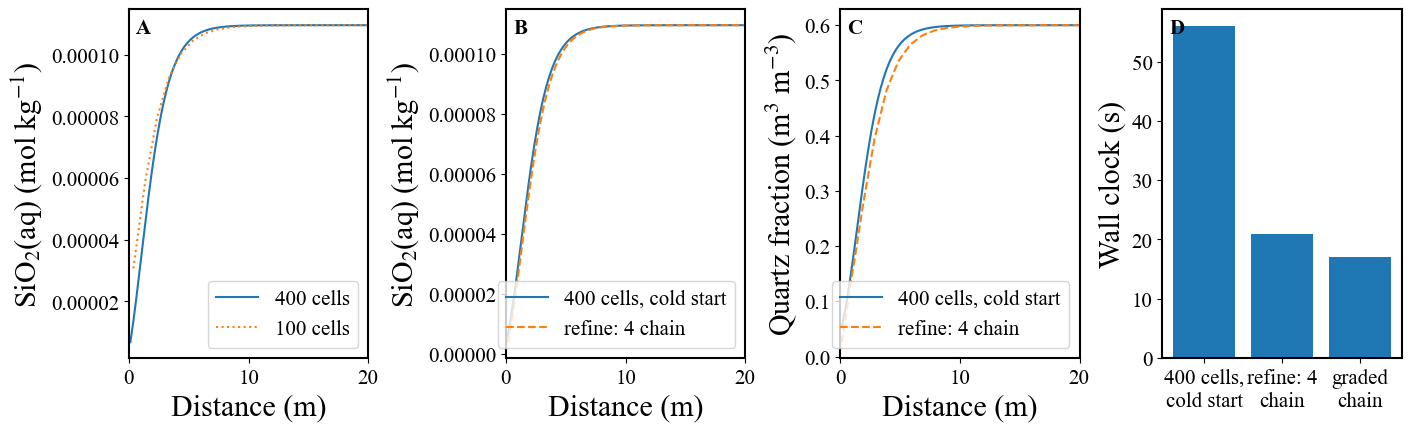

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), constrained_layout=True)

inlet = 20.0

# Each panel compares two profiles at the same simulated time.
ax = axes[0]
ax.plot(x_ref45, si_ref45, label='400 cells')
ax.plot(x_coarse, si_coarse, linestyle=':', label='100 cells')
ax.set_xlim(0, inlet)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SiO$_2$(aq) (mol kg$^{-1}$)')
ax.legend(loc='lower right')

ax = axes[1]
ax.plot(x_ref50, si_ref50, label='400 cells, cold start')
ax.plot(x_chain, si_chain, linestyle='--', label='refine: 4 chain')
ax.set_xlim(0, inlet)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SiO$_2$(aq) (mol kg$^{-1}$)')
ax.legend(loc='lower right')

ax = axes[2]
ax.plot(q_ref[0], q_ref[1], label='400 cells, cold start')
ax.plot(q_chain[0], q_chain[1], linestyle='--', label='refine: 4 chain')
ax.set_xlim(0, inlet)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Quartz fraction (m$^3$ m$^{-3}$)')
ax.legend(loc='lower right')

ax = axes[3]
ax.bar(list(WALL_CLOCK), list(WALL_CLOCK.values()))
ax.set_ylabel('Wall clock (s)')

for ax, letter in zip(axes, 'ABCD'):
    ax.text(0.03, 0.97, letter, transform=ax.transAxes, fontweight='bold',
            va='top', ha='left')

fig.savefig('grid_refinement_chain.png', dpi=200)

**A** — 4500 yr, the moment the chain refines. The coarse grid the chain starts from is visibly off
the fine answer at the inlet: this is resolution error with elapsed time held fixed.

**B** — 5000 yr, after 500 yr on the refined grid. The chain now sits on the cold-start curve.

**C** — the quartz volume fraction at 5000 yr, where the two still disagree. This is the coarse
stage's 4500 yr of mineral dissolution, inherited through the restart and not undone by refining.

**D** — what it cost.